# Evaluación Formativa 1 — Fase 1
## Online Shoppers Purchasing Intention

**Asignatura:** Estadística Computacional para la Toma de Decisiones (MCDI501)  
**Programa:** Magíster en Ciencia de Datos e Inteligencia Artificial  
**Universidad:** Universidad Andrés Bello  
**Semana:** 1  

### Objetivo
Comprender una problemática real mediante la exploración del conjunto de datos **Online Shoppers Purchasing Intention**, identificando sus variables, clasificándolas según su tipo y examinando relaciones preliminares que puedan apoyar la toma de decisiones bajo incertidumbre.

### Pregunta de análisis
**¿Qué características del comportamiento de navegación de los usuarios se relacionan con la probabilidad de que una sesión de comercio electrónico termine en una compra?**

> **Alcance:** este análisis identifica asociaciones estadísticas y patrones preliminares. No se interpretarán como relaciones causales.


## 1. Contexto y descripción del conjunto de datos

El conjunto de datos **Online Shoppers Purchasing Intention** contiene información de **12.330 sesiones** de navegación en un sitio de comercio electrónico. Combina variables relacionadas con páginas visitadas, duración de navegación, métricas de Google Analytics y características de la sesión.

La variable de resultado es **`Revenue`**, que indica si la sesión terminó (`True`) o no (`False`) en una compra.

**Fuente:** UCI Machine Learning Repository — *Online Shoppers Purchasing Intention Dataset*.

En esta etapa se conserva el archivo original sin modificaciones en `data/raw/`.


## 2. Importación de librerías


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

## 3. Carga reproducible de los datos

El bloque siguiente permite ejecutar el notebook tanto desde la carpeta `notebooks/` como desde la raíz del repositorio.


In [2]:
rutas_posibles = [
    Path("../data/raw/online_shoppers_intention.csv"),
    Path("data/raw/online_shoppers_intention.csv"),
]

ruta = next((p for p in rutas_posibles if p.exists()), None)

if ruta is None:
    raise FileNotFoundError(
        "No se encontró 'online_shoppers_intention.csv'. "
        "Verifique que esté en data/raw/."
    )

df = pd.read_csv(ruta)

print(f"Archivo cargado: {ruta.resolve()}")
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.head()


Archivo cargado: C:\Users\eliza\Desktop\ESTUDIOS\MAGÍSTER\2 ESTADÍSITICAS COMPUTACIONAL\Proyecto Estadística\Online-Shoppers-Purchasing-Intention\data\raw\online_shoppers_intention.csv
Dimensiones: 12,330 filas x 18 columnas


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 4. Reconocimiento inicial de la base

Antes de calcular estadísticas se revisan dimensiones, nombres de columnas, tipos computacionales, valores faltantes, duplicados y categorías. Esta etapa permite verificar que la estructura del archivo corresponda con lo esperado y evita aplicar procedimientos estadísticos a variables mal clasificadas.


In [3]:
print("Dimensiones:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())


Dimensiones: (12330, 18)

Columnas:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [5]:
resumen_calidad = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_no_nulos": df.notna().sum(),
    "n_nulos": df.isna().sum(),
    "pct_nulos": (df.isna().mean() * 100).round(2),
    "n_unicos": df.nunique(dropna=False)
})

resumen_calidad


,dtype,n_no_nulos,n_nulos,pct_nulos,n_unicos
Administrative,int64,12330,0,0.0,27
Administrative_Duration,float64,12330,0,0.0,3335
Informational,int64,12330,0,0.0,17
Informational_Duration,float64,12330,0,0.0,1258
ProductRelated,int64,12330,0,0.0,311
ProductRelated_Duration,float64,12330,0,0.0,9551
BounceRates,float64,12330,0,0.0,1872
ExitRates,float64,12330,0,0.0,4777
PageValues,float64,12330,0,0.0,2704
SpecialDay,float64,12330,0,0.0,6


In [6]:
duplicados = df.duplicated().sum()

print(f"Filas duplicadas exactas: {duplicados}")
print(f"Porcentaje de duplicados: {duplicados / len(df) * 100:.2f}%")


Filas duplicadas exactas: 125
Porcentaje de duplicados: 1.01%


### Interpretación de calidad de datos

Se verificará si existen valores faltantes o registros duplicados. Los duplicados se **reportan**, pero no se eliminan automáticamente en esta fase: primero debe justificarse si corresponden a registros repetidos o a sesiones distintas con las mismas características observadas.


## 5. Identificación y clasificación estadística de las variables

La clasificación estadística no depende únicamente del `dtype` de pandas. Por ejemplo, una variable almacenada como entero puede representar una categoría codificada y, por tanto, ser cualitativa nominal.

La siguiente tabla documenta la clasificación utilizada en el proyecto.


In [7]:
clasificacion = pd.DataFrame([
    ["Administrative", "Cuantitativa", "Discreta", "Número de páginas administrativas visitadas"],
    ["Administrative_Duration", "Cuantitativa", "Continua", "Tiempo dedicado a páginas administrativas"],
    ["Informational", "Cuantitativa", "Discreta", "Número de páginas informativas visitadas"],
    ["Informational_Duration", "Cuantitativa", "Continua", "Tiempo dedicado a páginas informativas"],
    ["ProductRelated", "Cuantitativa", "Discreta", "Número de páginas relacionadas con productos visitadas"],
    ["ProductRelated_Duration", "Cuantitativa", "Continua", "Tiempo dedicado a páginas de productos"],
    ["BounceRates", "Cuantitativa", "Continua", "Tasa de rebote"],
    ["ExitRates", "Cuantitativa", "Continua", "Tasa de salida"],
    ["PageValues", "Cuantitativa", "Continua", "Valor de página asociado a la sesión"],
    ["SpecialDay", "Cuantitativa", "Continua", "Cercanía de la sesión a una fecha especial"],
    ["Month", "Cualitativa", "Ordinal/temporal", "Mes de la sesión"],
    ["OperatingSystems", "Cualitativa", "Nominal", "Sistema operativo codificado"],
    ["Browser", "Cualitativa", "Nominal", "Navegador codificado"],
    ["Region", "Cualitativa", "Nominal", "Región codificada"],
    ["TrafficType", "Cualitativa", "Nominal", "Tipo/fuente de tráfico codificado"],
    ["VisitorType", "Cualitativa", "Nominal", "Tipo de visitante"],
    ["Weekend", "Cualitativa", "Nominal dicotómica", "Indica si la sesión ocurrió en fin de semana"],
    ["Revenue", "Cualitativa", "Nominal dicotómica", "Indica si la sesión terminó en compra"],
], columns=["Variable", "Naturaleza", "Tipo", "Descripción"])

clasificacion


,Variable,Naturaleza,Tipo,Descripción
0,Administrative,Cuantitativa,Discreta,Número de páginas administrativas visitadas
1,Administrative_Duration,Cuantitativa,Continua,Tiempo dedicado a páginas administrativas
2,Informational,Cuantitativa,Discreta,Número de páginas informativas visitadas
3,Informational_Duration,Cuantitativa,Continua,Tiempo dedicado a páginas informativas
4,ProductRelated,Cuantitativa,Discreta,Número de páginas relacionadas con productos v...
5,ProductRelated_Duration,Cuantitativa,Continua,Tiempo dedicado a páginas de productos
6,BounceRates,Cuantitativa,Continua,Tasa de rebote
7,ExitRates,Cuantitativa,Continua,Tasa de salida
8,PageValues,Cuantitativa,Continua,Valor de página asociado a la sesión
9,SpecialDay,Cuantitativa,Continua,Cercanía de la sesión a una fecha especial


### Criterio de clasificación

- **Cuantitativas discretas:** representan conteos.
- **Cuantitativas continuas:** representan duración, tasas o medidas que pueden tomar valores en un intervalo.
- **Cualitativas nominales:** identifican categorías sin una jerarquía estadística.
- **`Month`:** se conserva como categoría temporal; no se interpretará su código mediante medias.
- **`Revenue`:** es la variable objetivo y representa compra/no compra.

Esta clasificación determinará qué medidas y gráficos son pertinentes para cada variable.


## 6. Estadística descriptiva

### 6.1 Variables cuantitativas

Para las variables cuantitativas se calculan medidas de tendencia central y dispersión. Se incluyen media y mediana porque una diferencia importante entre ambas puede sugerir asimetría. La desviación estándar y el rango intercuartílico permiten describir la dispersión.


In [8]:
variables_cuantitativas = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
]

resumen_num = df[variables_cuantitativas].describe().T
resumen_num["mediana"] = df[variables_cuantitativas].median()
resumen_num["varianza"] = df[variables_cuantitativas].var()
resumen_num["IQR"] = (
    df[variables_cuantitativas].quantile(0.75)
    - df[variables_cuantitativas].quantile(0.25)
)
resumen_num["CV_%"] = (
    df[variables_cuantitativas].std()
    / df[variables_cuantitativas].mean().replace(0, np.nan)
    * 100
)
resumen_num["asimetria"] = df[variables_cuantitativas].skew()
resumen_num["curtosis"] = df[variables_cuantitativas].kurt()

resumen_num.round(3)


,count,mean,std,min,25%,50%,75%,max,mediana,varianza,IQR,CV_%,asimetria,curtosis
Administrative,12330.0,2.315,3.322,0.0,0.000,1.000,4.000,27.000,1.000,11.034,4.000,143.479,1.960,4.701
Administrative_Duration,12330.0,80.819,176.779,0.0,0.000,7.500,93.256,3398.750,7.500,31250.853,93.256,218.736,5.616,50.557
Informational,12330.0,0.504,1.270,0.0,0.000,0.000,0.000,24.000,0.000,1.613,0.000,252.231,4.036,26.932
Informational_Duration,12330.0,34.472,140.749,0.0,0.000,0.000,0.000,2549.375,0.000,19810.364,0.000,408.296,7.579,76.317
ProductRelated,12330.0,31.731,44.476,0.0,7.000,18.000,38.000,705.000,18.000,1978.070,31.000,140.162,4.342,31.212
ProductRelated_Duration,12330.0,1194.746,1913.669,0.0,184.138,598.937,1464.157,63973.522,598.937,3662130.143,1280.020,160.174,7.263,137.174
BounceRates,12330.0,0.022,0.048,0.0,0.000,0.003,0.017,0.200,0.003,0.002,0.017,218.501,2.948,7.723
ExitRates,12330.0,0.043,0.049,0.0,0.014,0.025,0.050,0.200,0.025,0.002,0.036,112.824,2.149,4.017
PageValues,12330.0,5.889,18.568,0.0,0.000,0.000,0.000,361.764,0.000,344.787,0.000,315.293,6.383,65.636
SpecialDay,12330.0,0.061,0.199,0.0,0.000,0.000,0.000,1.000,0.000,0.040,0.000,323.825,3.303,9.914


### 6.2 Variables cualitativas

Para las variables categóricas son más pertinentes las frecuencias y proporciones que la media.


In [9]:
variables_categoricas = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend",
    "Revenue",
]

for col in variables_categoricas:
    tabla = pd.DataFrame({
        "Frecuencia": df[col].value_counts(dropna=False),
        "Porcentaje": (df[col].value_counts(normalize=True, dropna=False) * 100).round(2)
    })
    print(f"\n--- {col} ---")
    print(tabla)



--- Month ---
       Frecuencia  Porcentaje
Month                        
May          3364       27.28
Nov          2998       24.31
Mar          1907       15.47
Dec          1727       14.01
Oct           549        4.45
Sep           448        3.63
Aug           433        3.51
Jul           432        3.50
June          288        2.34
Feb           184        1.49

--- OperatingSystems ---
                  Frecuencia  Porcentaje
OperatingSystems                        
2                       6601       53.54
1                       2585       20.97
3                       2555       20.72
4                        478        3.88
8                         79        0.64
6                         19        0.15
7                          7        0.06
5                          6        0.05

--- Browser ---
         Frecuencia  Porcentaje
Browser                        
2              7961       64.57
1              2462       19.97
4               736        5.97
5           

## 7. Distribución de la variable objetivo: Revenue

Antes de estudiar relaciones con otras variables se caracteriza el resultado principal. Esto también permite identificar si existe desbalance entre sesiones con compra y sin compra.


In [10]:
revenue_resumen = pd.DataFrame({
    "Frecuencia": df["Revenue"].value_counts(),
    "Porcentaje": (df["Revenue"].value_counts(normalize=True) * 100).round(2)
})
revenue_resumen


,Frecuencia,Porcentaje
Revenue,,
False,10422,84.53
True,1908,15.47


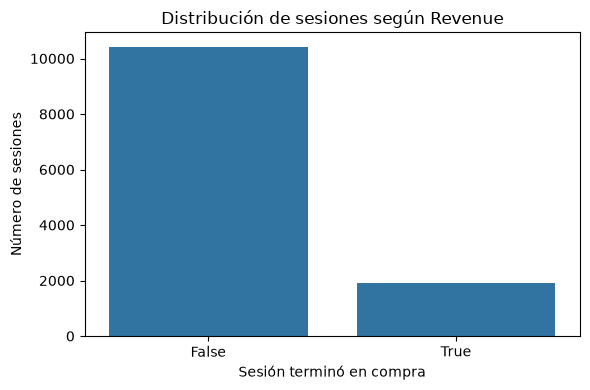

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Revenue")
plt.title("Distribución de sesiones según Revenue")
plt.xlabel("Sesión terminó en compra")
plt.ylabel("Número de sesiones")
plt.tight_layout()
plt.show()


### Interpretación

Se debe informar qué porcentaje de las sesiones termina en compra y qué porcentaje no. Si existe una diferencia marcada entre ambas categorías, debe mencionarse como **desbalance de clases**, ya que será relevante en etapas posteriores del proyecto.


## 8. Visualización de variables cuantitativas

Se seleccionan variables especialmente relacionadas con el comportamiento de navegación. Los histogramas permiten observar forma, concentración y asimetría; los boxplots permiten comparar distribuciones según `Revenue`.


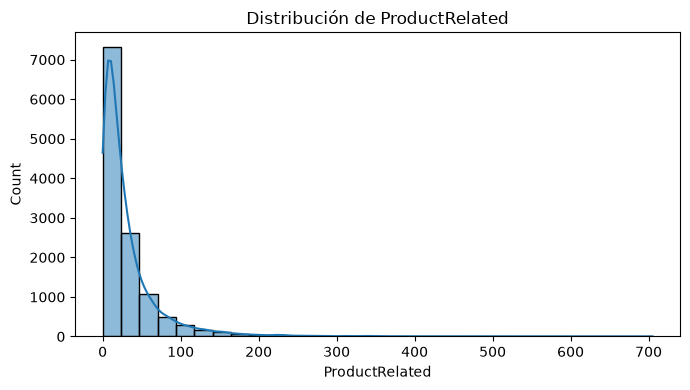

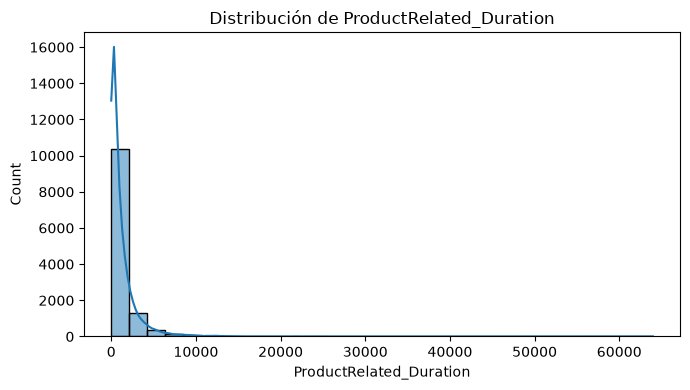

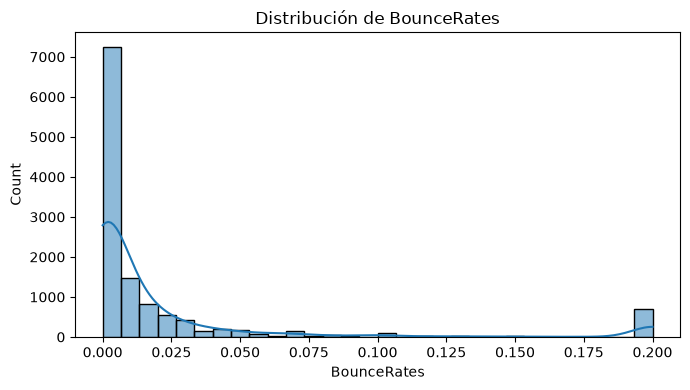

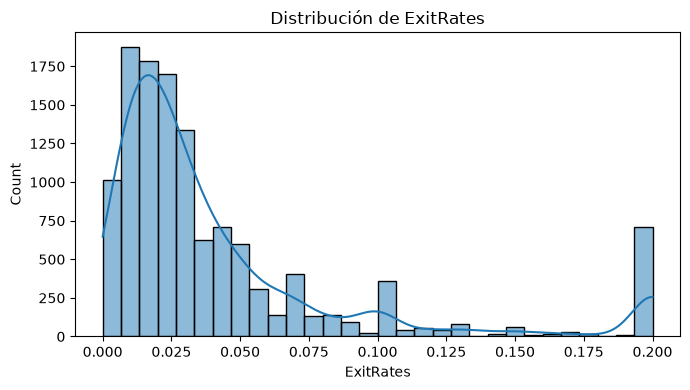

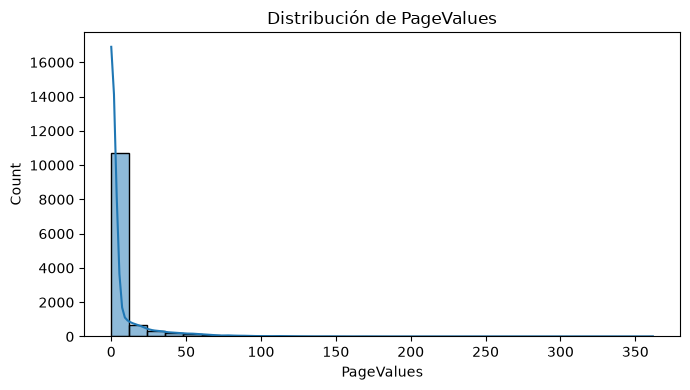

In [12]:
variables_graficos = [
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
]

for col in variables_graficos:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, bins=30, kde=True)
    plt.title(f"Distribución de {col}")
    plt.tight_layout()
    plt.show()


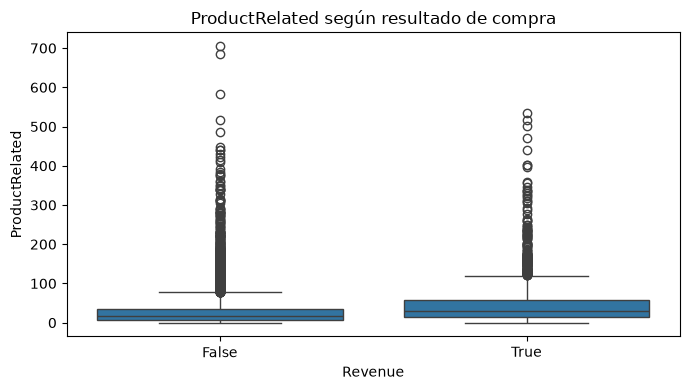

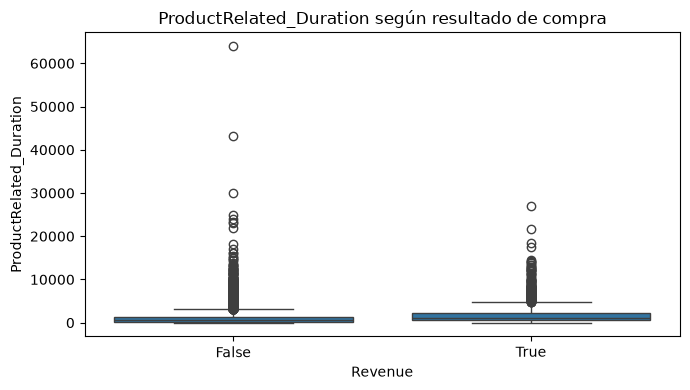

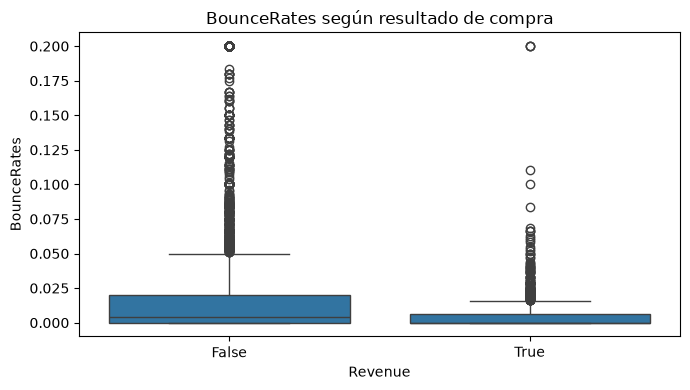

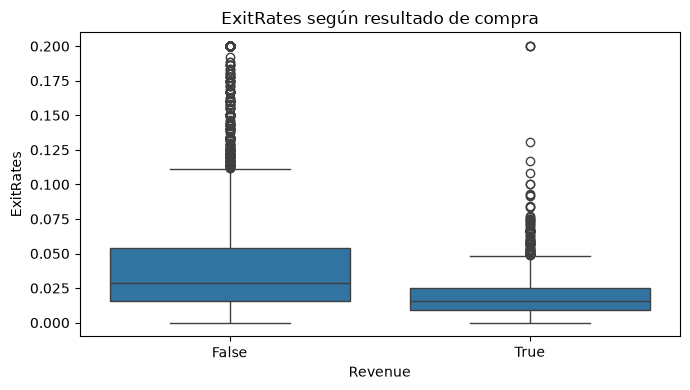

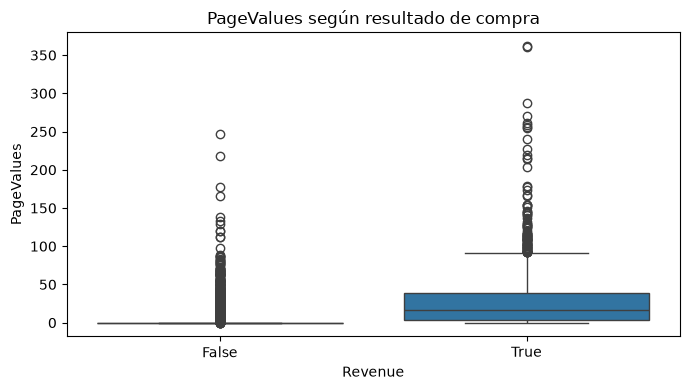

In [13]:
for col in variables_graficos:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Revenue", y=col)
    plt.title(f"{col} según resultado de compra")
    plt.xlabel("Revenue")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


## 9. Relaciones preliminares entre variables

### 9.1 Relación entre variables cuantitativas

La matriz de correlación permite identificar asociaciones lineales entre variables cuantitativas. Una correlación alta no implica causalidad y también puede advertir que dos variables contienen información similar.


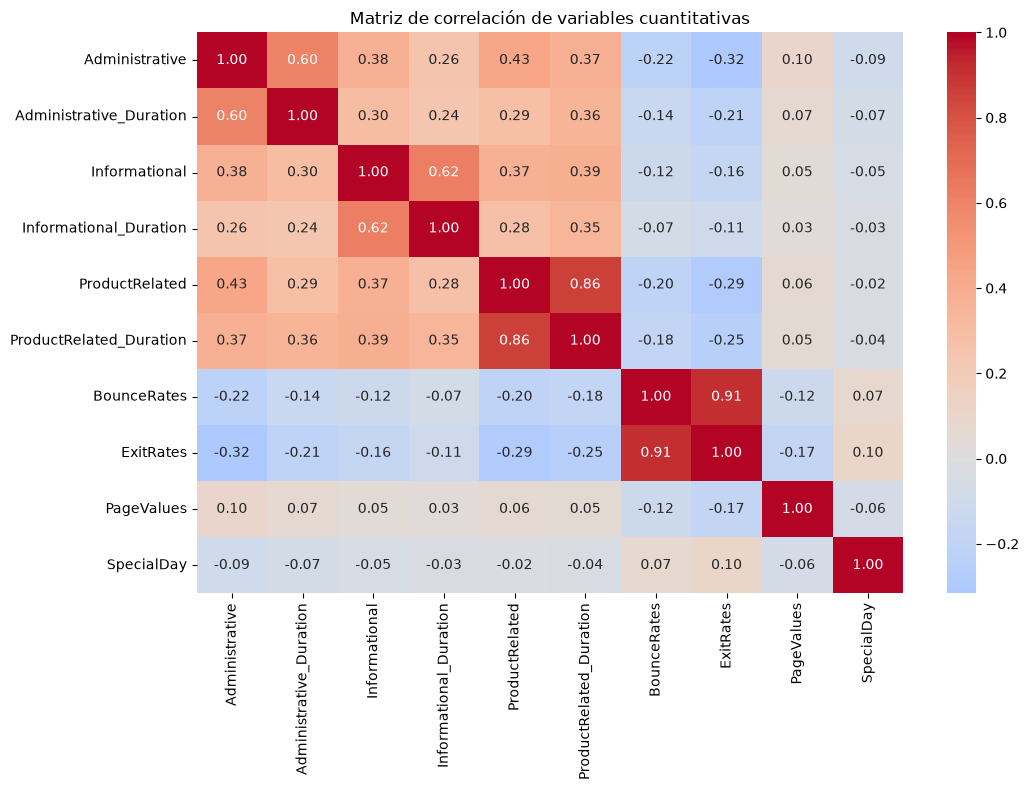

In [14]:
corr = df[variables_cuantitativas].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación de variables cuantitativas")
plt.tight_layout()
plt.show()


In [15]:
pares_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(key=abs, ascending=False)
        .rename("correlacion")
        .reset_index()
        .rename(columns={"level_0": "Variable_1", "level_1": "Variable_2"})
)

pares_corr.head(10)


,Variable_1,Variable_2,correlacion
0,BounceRates,ExitRates,0.913004
1,ProductRelated,ProductRelated_Duration,0.860927
2,Informational,Informational_Duration,0.618955
3,Administrative,Administrative_Duration,0.601583
4,Administrative,ProductRelated,0.431119
5,Informational,ProductRelated_Duration,0.387505
6,Administrative,Informational,0.376850
7,Informational,ProductRelated,0.374164
8,Administrative,ProductRelated_Duration,0.373939
9,Administrative_Duration,ProductRelated_Duration,0.355422


### 9.2 Variables categóricas y Revenue

Las tablas de contingencia permiten comparar la proporción de compra entre categorías. A continuación se exploran `VisitorType`, `Weekend` y `Month`.


In [16]:
for col in ["VisitorType", "Weekend", "Month"]:
    tabla = pd.crosstab(df[col], df["Revenue"], margins=True)
    print(f"\nTabla de contingencia: {col} vs Revenue")
    print(tabla)

    prop = pd.crosstab(df[col], df["Revenue"], normalize="index") * 100
    print("\nPorcentajes por categoría:")
    print(prop.round(2))



Tabla de contingencia: VisitorType vs Revenue
Revenue            False  True    All
VisitorType                          
New_Visitor         1272   422   1694
Other                 69    16     85
Returning_Visitor   9081  1470  10551
All                10422  1908  12330

Porcentajes por categoría:
Revenue            False  True 
VisitorType                    
New_Visitor        75.09  24.91
Other              81.18  18.82
Returning_Visitor  86.07  13.93

Tabla de contingencia: Weekend vs Revenue
Revenue  False  True    All
Weekend                    
False     8053  1409   9462
True      2369   499   2868
All      10422  1908  12330

Porcentajes por categoría:
Revenue  False  True 
Weekend              
False    85.11  14.89
True     82.60  17.40

Tabla de contingencia: Month vs Revenue
Revenue  False  True    All
Month                      
Aug        357    76    433
Dec       1511   216   1727
Feb        181     3    184
Jul        366    66    432
June       259    29    288
M

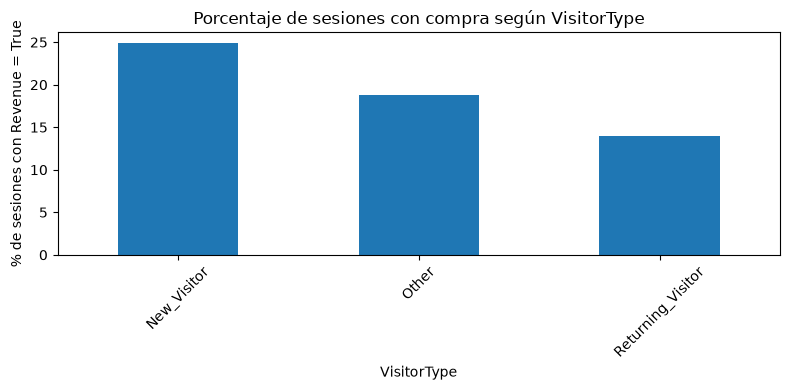

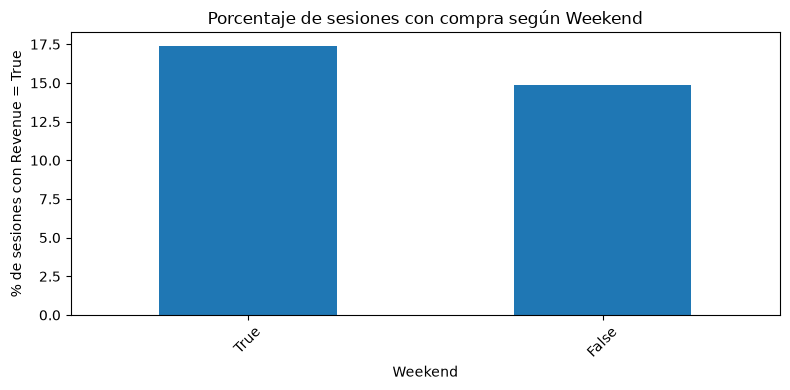

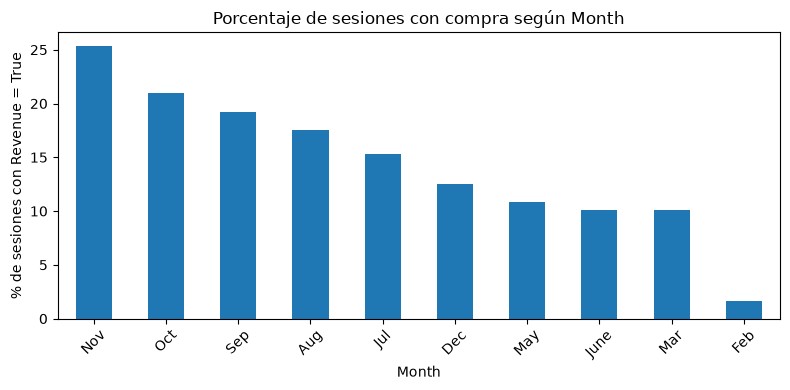

In [17]:
for col in ["VisitorType", "Weekend", "Month"]:
    prop_compra = (
        df.groupby(col, observed=False)["Revenue"]
          .mean()
          .mul(100)
          .sort_values(ascending=False)
    )

    plt.figure(figsize=(8, 4))
    prop_compra.plot(kind="bar")
    plt.title(f"Porcentaje de sesiones con compra según {col}")
    plt.ylabel("% de sesiones con Revenue = True")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## 10. Estimación puntual e intervalo de confianza

Para cubrir la estimación inferencial se estima la **proporción poblacional de sesiones que terminan en compra**.

La estimación puntual es la proporción observada de `Revenue = True`. Se construye además un intervalo de confianza del 95 % para esa proporción mediante la aproximación normal.


In [18]:
n = len(df)
x = df["Revenue"].astype(bool).sum()
p_hat = x / n

z = stats.norm.ppf(0.975)
se = np.sqrt(p_hat * (1 - p_hat) / n)

li = max(0, p_hat - z * se)
ls = min(1, p_hat + z * se)

print(f"Número de sesiones: {n:,}")
print(f"Sesiones con compra: {x:,}")
print(f"Estimación puntual de la proporción de compra: {p_hat:.4f} ({p_hat*100:.2f}%)")
print(f"IC 95% para la proporción: [{li:.4f}, {ls:.4f}]")
print(f"IC 95% en porcentaje: [{li*100:.2f}%, {ls*100:.2f}%]")


Número de sesiones: 12,330
Sesiones con compra: 1,908
Estimación puntual de la proporción de compra: 0.1547 (15.47%)
IC 95% para la proporción: [0.1484, 0.1611]
IC 95% en porcentaje: [14.84%, 16.11%]


### Interpretación del intervalo

El intervalo de confianza debe interpretarse en términos del **parámetro poblacional**: con el procedimiento utilizado se obtiene un rango plausible para la proporción de sesiones que terminan en compra. No debe interpretarse como que el 95 % de las observaciones se encuentra dentro del intervalo.


## 11. Prueba de hipótesis: VisitorType y Revenue

Se evaluará si existe asociación estadística entre el **tipo de visitante (`VisitorType`)** y el resultado de compra (`Revenue`).

### Hipótesis

- **H₀:** `VisitorType` y `Revenue` son independientes; no existe asociación estadística entre ambas variables.
- **H₁:** `VisitorType` y `Revenue` no son independientes; existe asociación estadística entre ambas variables.

Se utiliza una **prueba chi-cuadrado de independencia**, apropiada para analizar la relación entre dos variables categóricas.

**Nivel de significancia:** α = 0,05.


In [19]:
tabla_contingencia = pd.crosstab(df["VisitorType"], df["Revenue"])
tabla_contingencia


Revenue,False,True
VisitorType,,
New_Visitor,1272,422
Other,69,16
Returning_Visitor,9081,1470


In [20]:
chi2, p_valor, gl, esperadas = stats.chi2_contingency(tabla_contingencia)

esperadas_df = pd.DataFrame(
    esperadas,
    index=tabla_contingencia.index,
    columns=tabla_contingencia.columns
)

print(f"Chi-cuadrado: {chi2:.4f}")
print(f"Grados de libertad: {gl}")
print(f"p-valor: {p_valor:.6g}")
print(f"Frecuencia esperada mínima: {esperadas.min():.2f}")

alpha = 0.05

if p_valor < alpha:
    print("\nDecisión: se rechaza H₀ al nivel de significancia del 5%.")
    print("Existe evidencia estadística de asociación entre VisitorType y Revenue.")
else:
    print("\nDecisión: no se rechaza H₀ al nivel de significancia del 5%.")
    print("No se dispone de evidencia suficiente para afirmar una asociación entre VisitorType y Revenue.")

esperadas_df


Chi-cuadrado: 135.2519
Grados de libertad: 2
p-valor: 4.2699e-30
Frecuencia esperada mínima: 13.15

Decisión: se rechaza H₀ al nivel de significancia del 5%.
Existe evidencia estadística de asociación entre VisitorType y Revenue.


Revenue,False,True
VisitorType,,
New_Visitor,1431.862774,262.137226
Other,71.846715,13.153285
Returning_Visitor,8918.290511,1632.709489


## 12. Tamaño del efecto: V de Cramér

Un p-valor permite evaluar evidencia contra la hipótesis nula, pero no informa por sí solo la **magnitud** de la asociación. Por ello se calcula V de Cramér.


In [21]:
n_chi = tabla_contingencia.to_numpy().sum()
r, k = tabla_contingencia.shape

v_cramer = np.sqrt(chi2 / (n_chi * min(r - 1, k - 1)))

print(f"V de Cramér: {v_cramer:.4f}")


V de Cramér: 0.1047


### Interpretación conjunta

La conclusión de la prueba debe considerar:

1. El **p-valor**, para decidir si existe evidencia estadística de asociación.
2. El **V de Cramér**, para describir la magnitud de la asociación.
3. Las proporciones observadas por tipo de visitante, para interpretar la relación en el contexto del comercio electrónico.

Una asociación estadísticamente significativa **no demuestra causalidad**.


## 13. Análisis complementario: PageValues según Revenue

Como exploración adicional se compara descriptivamente `PageValues` entre sesiones con y sin compra. Esta sección ayuda a identificar si el comportamiento de esta variable cambia según el resultado de la sesión.


In [22]:
comparacion_pagevalues = (
    df.groupby("Revenue")["PageValues"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(3)
)

comparacion_pagevalues


,count,mean,median,std,min,max
Revenue,,,,,,
False,10422,1.976,0.000,9.072,0.0,246.759
True,1908,27.265,16.758,35.192,0.0,361.764


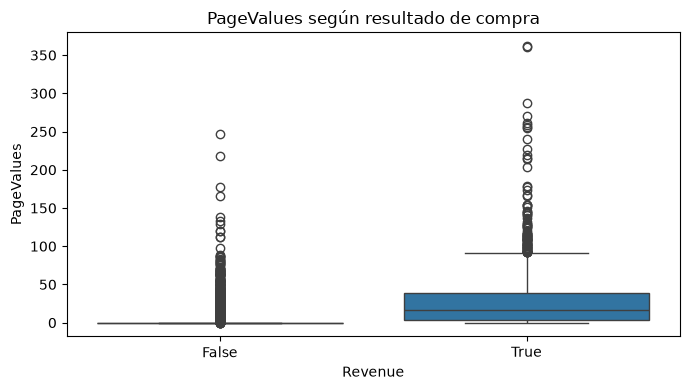

In [23]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="Revenue", y="PageValues")
plt.title("PageValues según resultado de compra")
plt.xlabel("Revenue")
plt.ylabel("PageValues")
plt.tight_layout()
plt.show()


## 14. Síntesis de relaciones preliminares

A partir de los resultados ejecutados, el equipo debe completar esta síntesis con los valores observados:

- **Conversión:** indicar el porcentaje de sesiones que termina en compra.
- **Comportamiento de navegación:** identificar qué variables muestran diferencias visibles entre sesiones con y sin compra.
- **Correlaciones:** señalar los pares de variables cuantitativas con asociaciones más altas y advertir que correlación no implica causalidad.
- **Tipo de visitante:** interpretar las proporciones de compra por `VisitorType` y el resultado de la prueba chi-cuadrado.
- **PageValues:** describir las diferencias observadas entre los grupos de `Revenue`.
- **Calidad de datos:** indicar presencia/ausencia de nulos y cantidad de duplicados detectados.

> **Importante:** las conclusiones deben redactarse después de ejecutar el notebook. No se deben anticipar resultados que no hayan sido observados en la salida del análisis.


## 15. Ficha descriptiva para la Evaluación Formativa 1

### Problema abordado
Comprender qué características observadas durante una sesión de navegación se relacionan con la finalización de una compra en un sitio de comercio electrónico.

### Unidad de análisis
Una sesión de navegación de un usuario.

### Variable de resultado
`Revenue`: variable cualitativa nominal dicotómica que indica si la sesión terminó o no en compra.

### Variables explicativas
El conjunto incluye variables cuantitativas relacionadas con páginas visitadas, duración, tasas de rebote/salida y valor de página; además de variables categóricas relacionadas con mes, sistema operativo, navegador, región, tráfico, tipo de visitante y fin de semana.

### Relaciones preliminares a estudiar
- Comportamiento de navegación y `Revenue`.
- `VisitorType` y `Revenue`.
- `Month` y `Revenue`.
- `Weekend` y `Revenue`.
- Relaciones entre métricas cuantitativas de navegación.

### Alcance
El análisis es exploratorio e inferencial inicial. Las asociaciones encontradas no permiten establecer relaciones causales.


## 16. Conclusiones

**Completar después de ejecutar y revisar todas las salidas.**

La conclusión final debe:

1. Responder la pregunta de análisis.
2. Incluir evidencia descriptiva concreta.
3. Interpretar el intervalo de confianza.
4. Informar la decisión de la prueba de hipótesis y su tamaño de efecto.
5. Relacionar los resultados con el problema de decisión bajo incertidumbre.
6. Reconocer que asociación no implica causalidad.
7. Evitar afirmaciones que los datos no permitan sostener.


## 17. Referencias

- Maidana, J. P. (2026). *Tipos de variables y exploración de datos con pandas*. Universidad Andrés Bello.
- Maidana, J. P. (2026). *Bases de datos disponibles para el proyecto del curso*. Universidad Andrés Bello.
- UCI Machine Learning Repository. *Online Shoppers Purchasing Intention Dataset*.
- McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly Media.
- pandas Development Team. *pandas documentation*.
